#Phase 1 SupplyChain

###Loading DataSet Permanently

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
import pandas as pd
#Loading Dataset
path = "/content/drive/MyDrive/SupplyChainProject/DataCoSupplyChainDataset.csv"
df = pd.read_csv(path, encoding='latin1')
#Checking First 5 Rows
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


##**Basic Cleaning**

###1. Understanding the structure of the Dataset

* Shape : Returns Number of Rows and Columns and helps to identify the Size of the Dataset (Large/Small)

In [67]:
df.shape

(180519, 53)

* Info : is used to get a quick summary of your dataset (DataFrame).

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

Describe : used to see the statistical summary of numerical columns in your dataset.
* Shows outliers (from extreme min/max)
* Shows mean, median → helps choose imputation methods

In [69]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


###2. Check Missing Values

In [70]:
df.isnull().sum().sort_values(ascending=False)

,0
Product Description,180519
Order Zipcode,155679
Customer Lname,8
Customer Zipcode,3
Days for shipment (scheduled),0
Sales per customer,0
Benefit per order,0
Delivery Status,0
Late_delivery_risk,0
Customer City,0


* Product Description has 180,519 missing values, which is about 99.7% missing data.

* Order Zipcode has 155,679 missing values, which is about 86% missing data.
* Since both columns have a very high percentage of missing values (above 50%), they do not contain enough useful information for analysis. Keeping them may reduce data quality and introduce bias if we try to fill such a large amount of missing data.

In [71]:
df.columns = df.columns.str.strip()

In [72]:
for col in df.columns:
    print(f"'{col}'")

'Type'
'Days for shipping (real)'
'Days for shipment (scheduled)'
'Benefit per order'
'Sales per customer'
'Delivery Status'
'Late_delivery_risk'
'Category Id'
'Category Name'
'Customer City'
'Customer Country'
'Customer Email'
'Customer Fname'
'Customer Id'
'Customer Lname'
'Customer Password'
'Customer Segment'
'Customer State'
'Customer Street'
'Customer Zipcode'
'Department Id'
'Department Name'
'Latitude'
'Longitude'
'Market'
'Order City'
'Order Country'
'Order Customer Id'
'order date (DateOrders)'
'Order Id'
'Order Item Cardprod Id'
'Order Item Discount'
'Order Item Discount Rate'
'Order Item Id'
'Order Item Product Price'
'Order Item Profit Ratio'
'Order Item Quantity'
'Sales'
'Order Item Total'
'Order Profit Per Order'
'Order Region'
'Order State'
'Order Status'
'Order Zipcode'
'Product Card Id'
'Product Category Id'
'Product Description'
'Product Image'
'Product Name'
'Product Price'
'Product Status'
'shipping date (DateOrders)'
'Shipping Mode'


In [73]:
df.drop(columns=['Product Description', 'Order Zipcode'],
        inplace=True,
        errors='ignore')


In [74]:
'Product Description' in df.columns

False

In [75]:
'Order Zipcode' in df.columns

False

* As Customer Lname and Customer Zipcode contain only 8 and 3 missing values respectively (less than 0.01% of the dataset), I will drop those rows to maintain data consistency without impacting the overall analysis.

In [76]:
df.dropna(subset=['Customer Lname', 'Customer Zipcode'], inplace=True)
df.shape

(180508, 51)

In [77]:
df.isnull().sum().sort_values(ascending=False)

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


###3. Checking Duplicates

In [78]:
df.duplicated().sum()

np.int64(0)

* There are no duplicate records present in the dataset.

###4. Fixing Column Names
* This step standardizes column names by converting them to lowercase and replacing spaces with underscores, making them easier to reference and more consistent for analysis.
* Ex: Customer Name  →  customer_name

In [79]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['type', 'days_for_shipping_(real)', 'days_for_shipment_(scheduled)',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_email', 'customer_fname', 'customer_id',
       'customer_lname', 'customer_password', 'customer_segment',
       'customer_state', 'customer_street', 'customer_zipcode',
       'department_id', 'department_name', 'latitude', 'longitude', 'market',
       'order_city', 'order_country', 'order_customer_id',
       'order_date_(dateorders)', 'order_id', 'order_item_cardprod_id',
       'order_item_discount', 'order_item_discount_rate', 'order_item_id',
       'order_item_product_price', 'order_item_profit_ratio',
       'order_item_quantity', 'sales', 'order_item_total',
       'order_profit_per_order', 'order_region', 'order_state', 'order_status',
       'product_card_id', 'product_category_id', 'product_image',
       'product_na

###5. Converting To Proper date column
* This step converts order_date and shipping_date from string format to datetime format so that we can perform date calculations and analysis. The parameter errors='coerce' ensures that invalid dates are converted to null values instead of causing errors.

In [80]:
df.rename(columns={
    'order_date_(dateorders)': 'order_date',
    'shipping_date_(dateorders)': 'shipping_date'
}, inplace=True)
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['shipping_date'] = pd.to_datetime(df['shipping_date'], errors='coerce')

###6. Checking Datatypes


In [81]:
df['customer_zipcode'] = df['customer_zipcode'].astype('Int64').astype(str)

In [82]:
df.dtypes

,0
type,object
days_for_shipping_(real),int64
days_for_shipment_(scheduled),int64
benefit_per_order,float64
sales_per_customer,float64
delivery_status,object
late_delivery_risk,int64
category_id,int64
category_name,object
customer_city,object


* After checking df.dtypes, I verified that numeric columns are correctly stored as int64 or float64, date columns are in datetime format, and categorical variables are stored as object. No major datatype corrections were required except minor adjustments if needed.
* I converted customer_zipcode from float to nullable integer to remove decimal points and then to string because zipcode is an identifier, not a numerical value for calculation.

###7. Created Delivery Days Feature
* I calculated delivery_days by subtracting order_date from shipping_date to measure the actual delivery time. This helps in analyzing shipping performance and identifying late deliveries.

In [83]:
df['delivery_days'] = (df['shipping_date'] - df['order_date']).dt.days

## **Exploratory Data Analysis (EDA)**

###1. Delivery Status Distribution
* Shows percentage of Late, On-time, Cancelled deliveries. Helps understand company delivery performance.

In [84]:
df['delivery_status'].value_counts(normalize=True)*100

,proportion
delivery_status,
Late delivery,54.829703
Advance shipping,23.039976
Shipping on time,17.834667
Shipping canceled,4.295654


* From the delivery status analysis, I observed that 54.83% of orders were delivered late, which indicates a major inefficiency in the logistics process. Only 17.83% were delivered on time, while 23.04% were delivered in advance. This suggests that the company needs to improve its delivery planning and supply chain management to reduce delays and improve customer satisfaction.


###2. Late Delivery Risk
* Shows How many orders were likely to be delayed?

In [85]:
df['late_delivery_risk'].value_counts()

,count
late_delivery_risk,
1,98972
0,81536


* (98972/180508)×100 = 55
* Around 55% of orders were marked as high risk for delay, which is similar to the actual late delivery percentage. This shows that delivery delays are common and the company needs to improve its logistics process.

###3. Category Analysis
* Shows top selling product categories. Helps business focus on high-demand categories.

In [86]:
df['category_name'].value_counts().head(10)

,count
category_name,
Cleats,24551
Men's Footwear,22246
Women's Apparel,21035
Indoor/Outdoor Games,19298
Fishing,17325
Water Sports,15540
Camping & Hiking,13729
Cardio Equipment,12487
Shop By Sport,10984


* From the category analysis, I observed that Cleats, Men's Footwear, and Women's Apparel are the top-selling categories, indicating strong demand for sports and apparel products. This insight helps the business focus more on high-performing categories.

###4.Region analysis
* Identifies top countries/regions like where most customers located. Helps in market expansion decisions.

In [87]:
df['customer_country'].value_counts().head(5)

,count
customer_country,
EE. UU.,111137
Puerto Rico,69371


* From the region analysis, I observed that the dataset contains customers only from EE. UU. (United States) and Puerto Rico, with the majority of customers from the U.S. This indicates that the company mainly operates within the U.S. market.

###5. Analyze Delivery days Distribution
* To see how delivery time is distributed and detect very high or negative values.

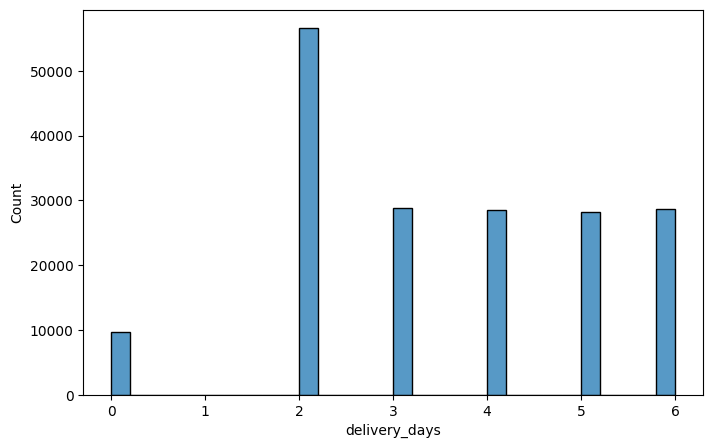

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['delivery_days'], bins=30)
plt.show()

* Most orders are delivered within 2–6 days, mainly around 2 days, with no negative values (clean data). However, higher delivery days may be contributing to the high late delivery rate.

###6. Comparision real vs scheduled delivery


In [89]:
(df['days_for_shipping_(real)'] - df['days_for_shipment_(scheduled)']).describe()

,0
count,180508.000000
mean,0.565836
std,1.490976
min,-2.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,4.000000


* Mean = 0.56 days -> On average, orders are delayed by around half a day.
* Median = 1 day -> Most orders are delayed by 1 day.
* Min = -2 days -> Some orders were delivered 2 days early (good).
* Max = 4 days -> Some orders were delayed by up to 4 days.
* 75% = 1 day -> 75% of orders are delayed by 1 day or less.
* Delays are small but frequent. Most delays are just 1 day, but they are happening consistently. This explains why late delivery percentage is high (54%).

###7. Sales VS Profit
* Checks relationship between sales and profit. High sales doesn’t always mean high profit.

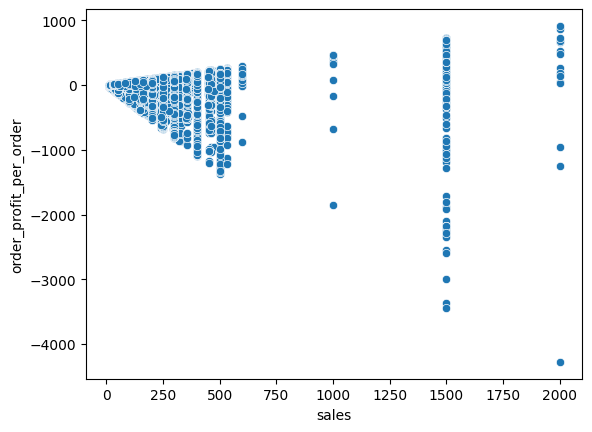

In [90]:
sns.scatterplot(x='sales', y='order_profit_per_order', data=df)
plt.show()

* The Sales vs Profit analysis shows a positive relationship between sales and profit. However, several orders generate negative profit, even at higher sales values, indicating possible discount or cost management issues.

###8. Department Performance
* Identifies Department causing delays. Helps improve vendor management.


In [91]:
df.groupby('department_name')['delivery_days'].mean().sort_values(ascending=False).head(10)

,delivery_days
department_name,
Discs Shop,3.533827
Outdoors,3.500826
Apparel,3.479281
Fitness,3.478822
Fan Shop,3.468614
Footwear,3.466850
Golf,3.463064
Health and Beauty,3.444751
Technology,3.429255


* So delays are consistent across departments, not just one department problem.

###9. Region Performance
* Identifies Region causing delays.

In [92]:
df.groupby('order_region')['delivery_days'].mean().sort_values(ascending=False)

,delivery_days
order_region,
Central Africa,3.546213
West Africa,3.510552
Eastern Asia,3.500069
East Africa,3.492441
Central America,3.486010
Eastern Europe,3.484439
Northern Europe,3.480082
West of USA,3.478794
Caribbean,3.478240


* Delays are happening everywhere slightly, not in one specific region.

###10. Category Performance
* Identifies Category causing delays.


In [93]:
df.groupby('category_name')['delivery_days'].mean().sort_values(ascending=False).head(10)

,delivery_days
category_name,
Strength Training,3.729730
Soccer,3.688406
As Seen on TV!,3.617647
DVDs,3.616977
Kids' Golf Clubs,3.609375
Computers,3.608597
Lacrosse,3.591837
Children's Clothing,3.588598
Crafts,3.567568


* Bulky items (like strength training equipment) may take longer due to shipping complexity.
* Electronics and specialty products may need special handling.
* However, variation is small → confirms delay issue is mostly operational, not category-based.

###11. KPI Calculation
* KPIs = Key Performance Indicators. Gives quick business summary in numbers.

In [94]:
print("Average Delivery Days:", df['delivery_days'].mean())
print("Total Sales:", df['sales'].sum())
print("Average Profit:", df['order_profit_per_order'].mean())
print("Total Profit:", df['order_profit_per_order'].sum())
print("Average Discount Rate:", df['order_item_discount_rate'].mean())

Average Delivery Days: 3.471873822766858
Total Sales: 36781302.123304136
Average Profit: 21.97156316640914
Total Profit: 3966042.924042181
Average Discount Rate: 0.10166818141168257


* The average delivery time is 3.47 days. The company generated total sales of 36.78 million with a total profit of 3.97 million. On average, each order contributes approximately 21.97 in profit. The average discount rate is around 10%, indicating moderate promotional activity.

###12. Correlation Heatmap
* It shows how numeric variables are related to each other.

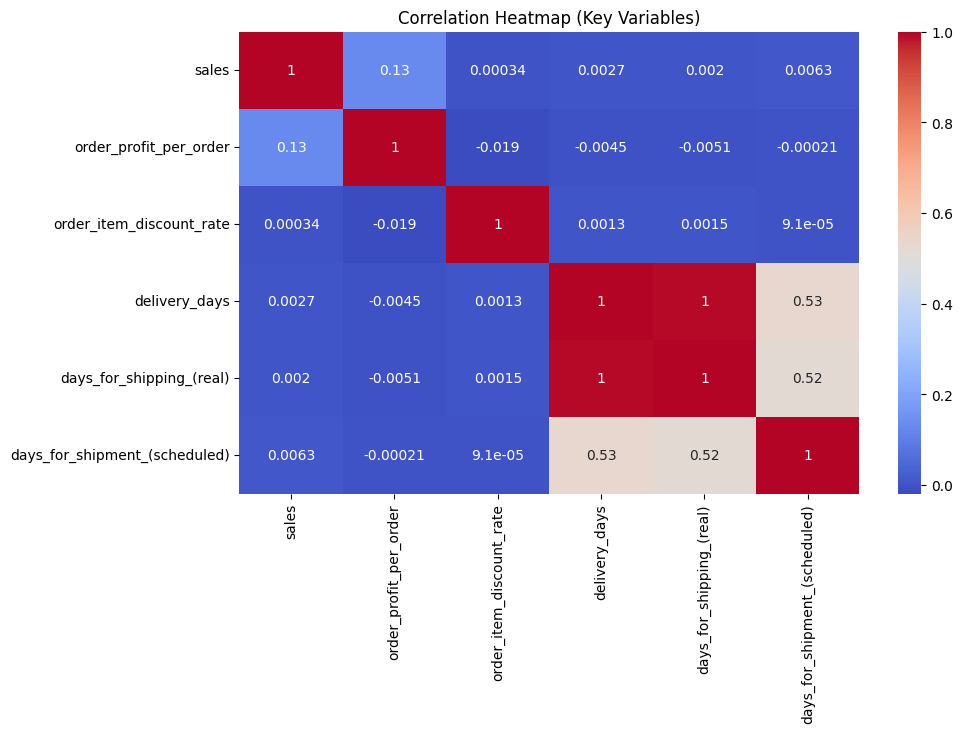

In [95]:
selected_cols = [
    'sales',
    'order_profit_per_order',
    'order_item_discount_rate',
    'delivery_days',
    'days_for_shipping_(real)',
    'days_for_shipment_(scheduled)'
]

corr_matrix = df[selected_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Key Variables)")
plt.show()

* Sales vs Profit → 0.13 Small positive relationship. When sales increase, profit increases slightly. But sales do not strongly control profit.
* Discount Rate vs Profit → -0.019 Very small negative relationship. Higher discounts slightly reduce profit.
* Delivery Days vs Real Shipping Days → 1.0 Perfect correlation. Both columns represent almost the same information. One of them can be removed in ML.
* Delivery Days vs Scheduled Shipping Days → 0.53 Moderate positive relationship. If scheduled days increase, real delivery days also increase.Scheduling directly affects delivery performance.

###13. Sales by Customer City


In [96]:
df.groupby('customer_city')['sales'].sum().sort_values(ascending=False).head(10)

,sales
customer_city,
Caguas,1.360969e+07
Chicago,7.976142e+05
Los Angeles,6.974259e+05
Brooklyn,6.764198e+05
New York,3.612171e+05
Philadelphia,3.157055e+05
Bronx,3.089050e+05
San Diego,2.938305e+05
Miami,2.703682e+05


* Sales analysis by customer city shows that Caguas contributes the highest revenue by a significant margin. Other cities like Chicago and Los Angeles generate moderate sales but far lower compared to Caguas. This indicates revenue concentration in one key location and highlights an opportunity to expand business in other cities.

###14. Category-wise Profit
* Which category is most profitable?

In [97]:
df.groupby('category_name')['order_profit_per_order'].mean().sort_values(ascending=False)

,order_profit_per_order
category_name,
Computers,157.594593
Garden,69.097128
Crafts,51.990042
Cameras,51.165203
Fishing,43.649106
Children's Clothing,41.621001
Sporting Goods,35.066135
Music,33.263410
Camping & Hiking,31.135230


* Profit analysis by category shows that Computers generate the highest average profit, followed by Garden and Crafts. However, categories like Toys, Books, and CDs have very low profit margins.

###15. Monthly Trend
* Shows Sales trend over time.

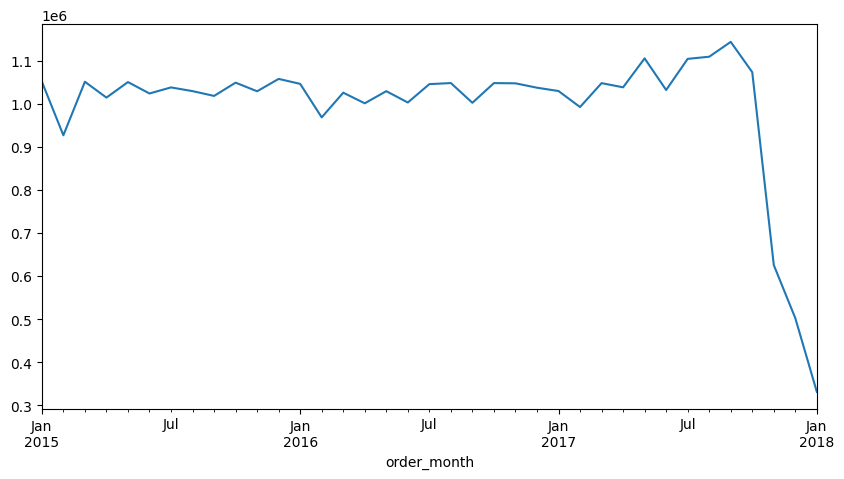

In [98]:
df['order_month'] = df['order_date'].dt.to_period('M')
df.groupby('order_month')['sales'].sum().plot(figsize=(10,5))
plt.show()

* Monthly sales remained stable from 2015 to 2017 with a slight growth trend. A peak is observed in mid-2017, indicating strong performance. The sudden drop observed at the end of the timeline is due to partial month data availability and does not indicate actual business decline.

##**Advanced Cleaning**
* Improving data quality based on insights from EDA.

###1. Outlier Detection & Treatment
* Outliers are extreme values that are very high or very low compared to normal data.

In [99]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"{column} → Lower: {lower}, Upper: {upper}")

    return df[(df[column] >= lower) & (df[column] <= upper)]


In [100]:
columns_to_clean = [
    'delivery_days',
    'days_for_shipping_(real)',
    'days_for_shipment_(scheduled)',
    'order_item_discount_rate'
]

print("Shape before outlier removal:", df.shape)

for col in columns_to_clean:
    df = remove_outliers_iqr(df, col)

print("Shape after outlier removal:", df.shape)

Shape before outlier removal: (180508, 53)
delivery_days → Lower: -2.5, Upper: 9.5
days_for_shipping_(real) → Lower: -2.5, Upper: 9.5
days_for_shipment_(scheduled) → Lower: -1.0, Upper: 7.0
order_item_discount_rate → Lower: -0.1399999965, Upper: 0.33999999150000004
Shape after outlier removal: (180508, 53)


* IQR-based outlier detection was applied on delivery and shipping-related features. No extreme outliers were detected, indicating that the dataset is operationally consistent and well-maintained.

###2. Creating Delay Flag
* A binary target variable delay_flag was created from the delivery_status column. Orders marked as "Late delivery" were encoded as 1, while all other statuses were encoded as 0. This transformation enables the dataset to be used for classification modeling to predict delivery delays.

In [101]:
df['delay_flag'] = df['delivery_status'].apply(
    lambda x: 1 if x == "Late delivery" else 0
)

df['delay_flag'].value_counts()



,count
delay_flag,
1,98972
0,81536


###3. Handling Skewness

In [102]:
df[['sales','delivery_days','order_profit_per_order']].skew()

,0
sales,2.884585
delivery_days,-0.026416
order_profit_per_order,-4.742050


Skewness before transformation:
sales                     2.884585
order_profit_per_order   -4.742050
dtype: float64

Skewness after transformation:
sales_log    -0.679429
profit_log   -0.472720
dtype: float64


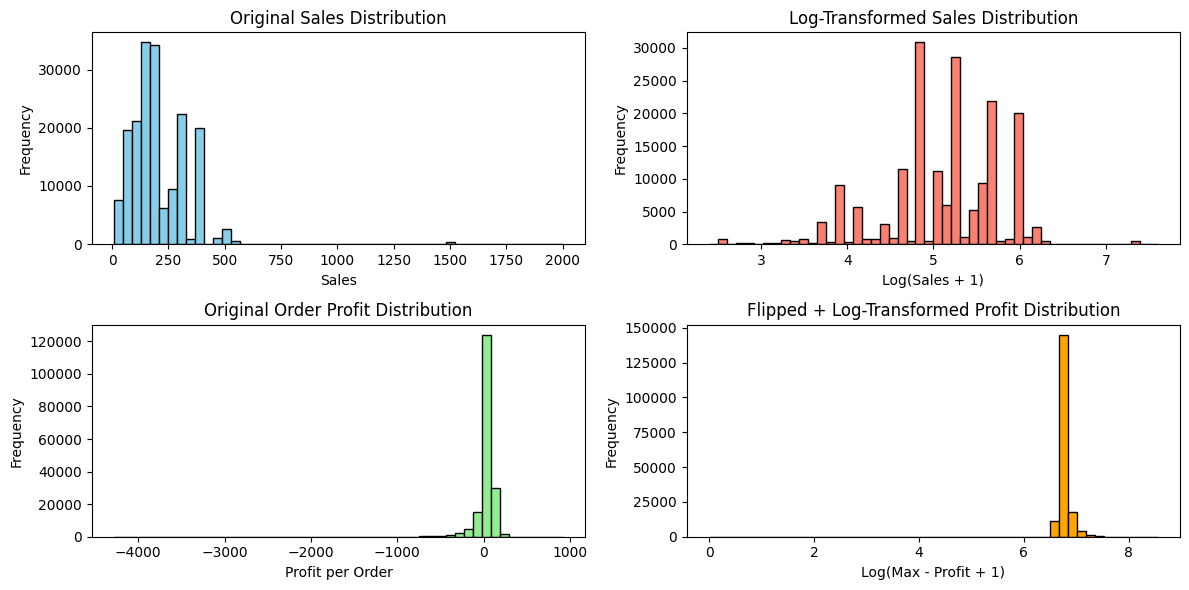

In [103]:
# Step 0: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Example - using your existing dataframe
# df = pd.read_csv("your_dataset.csv")  # Uncomment if reading from file

# Step 2: Check skewness before transformation
print("Skewness before transformation:")
print(df[['sales', 'order_profit_per_order']].skew())

# Step 3: Apply log transform to 'sales' (positively skewed)
df['sales_log'] = np.log1p(df['sales'])  # log(1 + x)

# Step 4: Apply flip + log transform to 'order_profit_per_order' (negatively skewed)
# Flip to make it positively skewed
max_profit = df['order_profit_per_order'].max()
df['profit_flipped'] = max_profit - df['order_profit_per_order']
df['profit_log'] = np.log1p(df['profit_flipped'])

# Step 5: Check skewness after transformation
print("\nSkewness after transformation:")
print(df[['sales_log', 'profit_log']].skew())

# Step 6: Plot before and after transformations
plt.figure(figsize=(12,6))

# Sales
plt.subplot(2,2,1)
plt.hist(df['sales'], bins=50, color='skyblue', edgecolor='black')
plt.title('Original Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.subplot(2,2,2)
plt.hist(df['sales_log'], bins=50, color='salmon', edgecolor='black')
plt.title('Log-Transformed Sales Distribution')
plt.xlabel('Log(Sales + 1)')
plt.ylabel('Frequency')

# Order Profit
plt.subplot(2,2,3)
plt.hist(df['order_profit_per_order'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Original Order Profit Distribution')
plt.xlabel('Profit per Order')
plt.ylabel('Frequency')

plt.subplot(2,2,4)
plt.hist(df['profit_log'], bins=50, color='orange', edgecolor='black')
plt.title('Flipped + Log-Transformed Profit Distribution')
plt.xlabel('Log(Max - Profit + 1)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

* Log transformation is effective: skewness reduced from ~3 to <1 for sales and from ~-5 to ~-0.47 for profit.
* Histograms visually confirm that the tails are compressed.
* These features are now ready for modeling, especially for models sensitive to skew.

In [104]:
# Check original vs transformed
print(df[['sales', 'sales_log', 'order_profit_per_order', 'profit_log']].head(10))

    sales  sales_log  order_profit_per_order  profit_log
0  327.75   5.795298               91.250000    6.711193
1  327.75   5.795298             -249.089996    7.057803
2  327.75   5.795298             -247.779999    7.056675
3  327.75   5.795298               22.860001    6.791154
4  327.75   5.795298              134.210007    6.657485
5  327.75   5.795298               18.580000    6.795952
6  327.75   5.795298               95.180000    6.706398
7  327.75   5.795298               68.430000    6.738591
8  327.75   5.795298              133.720001    6.658114
9  327.75   5.795298              132.149994    6.660127


### 4.Removing Irrelevant Columns

In [105]:
columns_to_drop = [
    'customer_email',
    'customer_password',
    'customer_fname',
    'customer_lname',
    'customer_street',
    'latitude',
    'longitude',
    'product_image'
]
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print("Columns removed successfully.")
print("New Shape:", df.shape)
print("Remaining Columns:\n", df.columns)

Columns removed successfully.
New Shape: (180508, 49)
Remaining Columns:
 Index(['type', 'days_for_shipping_(real)', 'days_for_shipment_(scheduled)',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_id', 'customer_segment', 'customer_state',
       'customer_zipcode', 'department_id', 'department_name', 'market',
       'order_city', 'order_country', 'order_customer_id', 'order_date',
       'order_id', 'order_item_cardprod_id', 'order_item_discount',
       'order_item_discount_rate', 'order_item_id', 'order_item_product_price',
       'order_item_profit_ratio', 'order_item_quantity', 'sales',
       'order_item_total', 'order_profit_per_order', 'order_region',
       'order_state', 'order_status', 'product_card_id', 'product_category_id',
       'product_name', 'product_price', 'product_status', 'shipping_date',
       'shipping_mode', 'delivery_days'

###5. Checking Class Imbalance

In [106]:
# Count of each class
print(df['delay_flag'].value_counts())

# Percentage
print(df['delay_flag'].value_counts(normalize=True) * 100)

delay_flag
1    98972
0    81536
Name: count, dtype: int64
delay_flag
1    54.829703
0    45.170297
Name: proportion, dtype: float64


###6. Removing Highly Correlated Features
* When two features are very strongly correlated (correlation > 0.9 or < -0.9):
They carry almost the same information. Models like linear regression or logistic regression can become unstable (high variance in coefficients).

In [107]:
import pandas as pd

# Only numeric columns
corr_matrix = df.corr(numeric_only=True)

# Display high correlations
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# Show highly correlated pairs
for col1, col2, corr_value in high_corr:
    print(f"{col1} and {col2} => correlation: {corr_value:.2f}")

order_customer_id and customer_id => correlation: 1.00
order_item_cardprod_id and category_id => correlation: 0.99
order_item_cardprod_id and department_id => correlation: 0.91
order_item_id and order_id => correlation: 1.00
sales and sales_per_customer => correlation: 0.99
order_item_total and sales_per_customer => correlation: 1.00
order_item_total and sales => correlation: 0.99
order_profit_per_order and benefit_per_order => correlation: 1.00
product_card_id and category_id => correlation: 0.99
product_card_id and department_id => correlation: 0.91
product_card_id and order_item_cardprod_id => correlation: 1.00
product_category_id and category_id => correlation: 1.00
product_category_id and order_item_cardprod_id => correlation: 0.99
product_category_id and product_card_id => correlation: 0.99
product_price and order_item_product_price => correlation: 1.00
delivery_days and days_for_shipping_(real) => correlation: 1.00
delay_flag and late_delivery_risk => correlation: 1.00
profit_fl

In [108]:
# List of columns to drop
cols_to_drop = [
    'customer_id',
    'order_item_cardprod_id',
    'order_item_id',
    'sales_per_customer',
    'benefit_per_order',
    'product_card_id',
    'product_category_id',
    'order_item_product_price',
    'profit_flipped'
]

# Drop the columns from the DataFrame
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Confirmation
print("Columns dropped successfully!")
print("New Shape of DataFrame:", df.shape)
print("Remaining Columns:\n", df.columns)

Columns dropped successfully!
New Shape of DataFrame: (180508, 40)
Remaining Columns:
 Index(['type', 'days_for_shipping_(real)', 'days_for_shipment_(scheduled)',
       'delivery_status', 'late_delivery_risk', 'category_id', 'category_name',
       'customer_city', 'customer_country', 'customer_segment',
       'customer_state', 'customer_zipcode', 'department_id',
       'department_name', 'market', 'order_city', 'order_country',
       'order_customer_id', 'order_date', 'order_id', 'order_item_discount',
       'order_item_discount_rate', 'order_item_profit_ratio',
       'order_item_quantity', 'sales', 'order_item_total',
       'order_profit_per_order', 'order_region', 'order_state', 'order_status',
       'product_name', 'product_price', 'product_status', 'shipping_date',
       'shipping_mode', 'delivery_days', 'order_month', 'delay_flag',
       'sales_log', 'profit_log'],
      dtype='object')


###7. Noise reduction in string or categorical columns

In [118]:
text_cols = [
    'type', 'delivery_status', 'category_name', 'customer_city', 'customer_country',
    'customer_segment', 'customer_state', 'customer_zipcode', 'department_name',
    'market', 'order_city', 'order_country', 'order_region', 'order_state',
    'order_status', 'product_name', 'shipping_mode'
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

* Noise reduction in string columns cleans text by removing extra spaces and converting all entries to lowercase, so variations like " Hyderabad " and "HYDERABAD" are treated the same. This ensures consistent categories, improves ML feature quality, prevents duplicate categories, and makes aggregations and visualizations accurate. Common typos can also be corrected using mapping dictionaries or fuzzy matching

###8. Extract useful features from date columns

In [119]:
df['order_day'] = df['order_date'].dt.day
df['order_week'] = df['order_date'].dt.isocalendar().week
df['order_month'] = df['order_date'].dt.month
df['is_weekend'] = df['order_date'].dt.dayofweek >= 5

###**Saving the Cleaned Dataset**

In [120]:
# 1️⃣ Save the cleaned dataset
df.to_csv("supplychain_cleaned.csv", index=False)

# 2️⃣ Download the file to your local computer
from google.colab import files
files.download("supplychain_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>